# ETF 融资买入资金赚钱效应

固定首日 ETF 样本，展示融资买入覆盖率与日度资金批次的累计盈利资金比例。入场价为日成交额÷（成交量×100），评估价为后复权收盘价。

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
SOURCE = ROOT / 'data/source/margin'
DERIVED = ROOT / 'data/derived/margin'
OUTPUT = ROOT / 'output/margin'
ANALYSIS_START = pd.Timestamp('2026-01-01')
BASE_COVERAGE = 0.80
WARNING_COVERAGE = 0.70
margin = pd.read_parquet(DERIVED / 'etf_financing_buy.parquet')
prices = pd.read_parquet(SOURCE / 'etf_margin_prices.parquet')
margin['trade_date'] = pd.to_datetime(margin['trade_date'])
prices['trade_date'] = pd.to_datetime(prices['trade_date'])
margin = margin.loc[margin['trade_date'] >= ANALYSIS_START].copy()
prices = prices.loc[prices['trade_date'] >= ANALYSIS_START].copy()
assert {'trade_date', 'exchange', 'security_code', 'financing_buy_amount'} <= set(margin.columns)
assert {'trade_date', 'exchange', 'security_code', 'close', 'close_unadjusted', 'volume', 'amount'} <= set(prices.columns)


使用中文字体：PingFang SC


In [2]:
# 首日固定样本：最小前缀达到 ETF 融资买入额的 80%。
base_date = margin['trade_date'].min()
base = margin.loc[(margin.trade_date == base_date) & (margin.financing_buy_amount > 0)].sort_values('financing_buy_amount', ascending=False).reset_index(drop=True)
base['base_rank'] = base.index + 1
base['base_share'] = base.financing_buy_amount / base.financing_buy_amount.sum()
base['base_cumulative_share'] = base.base_share.cumsum()
universe = base.loc[:base.base_cumulative_share.ge(BASE_COVERAGE).idxmax(), ['exchange', 'security_code', 'security_name', 'base_rank', 'base_share', 'base_cumulative_share']].copy()
universe['base_date'] = base_date
universe['base_margin_purchase'] = base.loc[universe.index, 'financing_buy_amount'].to_numpy()
assert universe.base_cumulative_share.iloc[-1] >= BASE_COVERAGE
assert len(universe) == 1 or universe.base_cumulative_share.iloc[-2] < BASE_COVERAGE
universe.to_parquet(DERIVED / 'fixed_etf_universe.parquet', index=False)
readable_universe = universe.rename(columns={'security_code': 'ETF代码', 'security_name': 'ETF简称', 'exchange': '交易所', 'base_date': '基准日', 'base_margin_purchase': '基准日融资买入额', 'base_rank': '基准日排名', 'base_share': '基准日金额占比', 'base_cumulative_share': '基准日累计占比'})
readable_universe = readable_universe[['ETF代码', 'ETF简称', '交易所', '基准日', '基准日融资买入额', '基准日排名', '基准日金额占比', '基准日累计占比']]
OUTPUT.mkdir(parents=True, exist_ok=True)
readable_universe.to_csv(OUTPUT / 'fixed_etf_universe.csv', index=False, encoding='utf-8-sig')
readable_universe


,ETF代码,ETF简称,交易所,基准日,基准日融资买入额,基准日排名,基准日金额占比,基准日累计占比
0,513090,香港证券,SSE,2026-01-05,1448276054,1,0.067564,0.067564
1,511360,短融ETF,SSE,2026-01-05,1394733966,2,0.065066,0.132630
2,513180,恒指科技,SSE,2026-01-05,967468264,3,0.045134,0.177763
3,513130,恒生科技,SSE,2026-01-05,887150633,4,0.041387,0.219150
4,510300,300ETF,SSE,2026-01-05,775813547,5,0.036193,0.255343
...,...,...,...,...,...,...,...,...
67,588170,科创半导,SSE,2026-01-05,59934351,68,0.002796,0.789782
68,510050,50ETF,SSE,2026-01-05,57696847,69,0.002692,0.792474
69,159851,金融科技ETF,SZSE,2026-01-05,56761225,70,0.002648,0.795122
70,159217,港股通创新药ETF工银,SZSE,2026-01-05,56115570,71,0.002618,0.797739


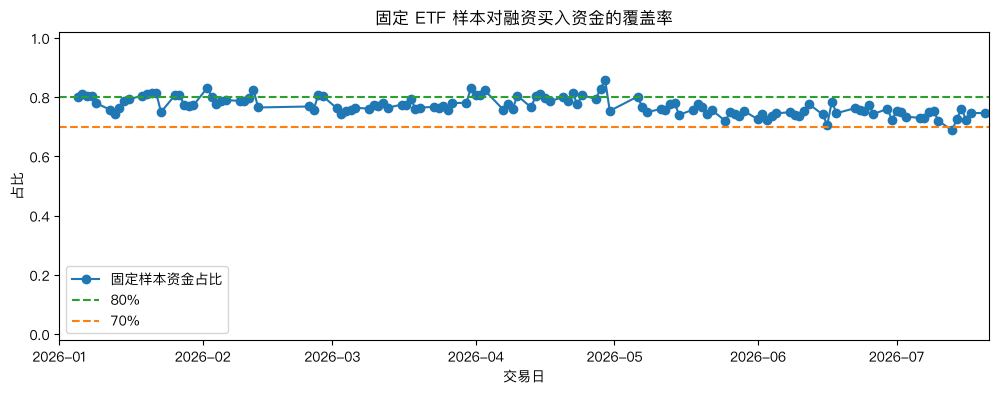

In [3]:
# 固定样本覆盖率。缺失样本记录仅在该交易日 ETF 明细完整时视为零。
all_daily = margin.groupby('trade_date', as_index=False).financing_buy_amount.sum().rename(columns={'financing_buy_amount': 'all_etf_margin_purchase'})
sample_daily = margin.merge(universe[['exchange', 'security_code']], on=['exchange', 'security_code']).groupby('trade_date', as_index=False).agg(sample_margin_purchase=('financing_buy_amount', 'sum'), sample_active_count=('security_code', 'nunique'))
coverage = all_daily.merge(sample_daily, on='trade_date', how='left').fillna({'sample_margin_purchase': 0, 'sample_active_count': 0})
coverage['sample_total_count'] = len(universe)
coverage['sample_coverage'] = coverage.sample_margin_purchase / coverage.all_etf_margin_purchase
coverage['coverage_below_80'] = coverage.sample_coverage < BASE_COVERAGE
coverage['coverage_below_warning'] = coverage.sample_coverage < WARNING_COVERAGE
assert coverage.sample_coverage.between(0, 1).all()
coverage.to_parquet(DERIVED / 'sample_coverage.parquet', index=False)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(coverage.trade_date, coverage.sample_coverage, marker='o', label='固定样本资金占比')
ax.axhline(BASE_COVERAGE, color='tab:green', ls='--', label='80%')
ax.axhline(WARNING_COVERAGE, color='tab:orange', ls='--', label='70%')
ax.set_xlim(ANALYSIS_START, prices.trade_date.max())
ax.set(title='固定 ETF 样本对融资买入资金的覆盖率', ylabel='占比', xlabel='交易日', ylim=(-0.02, 1.02))
ax.legend()
plt.show()


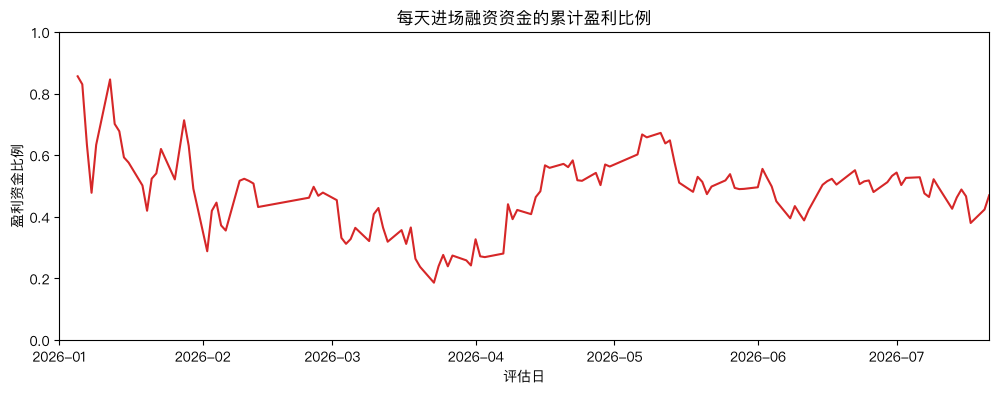

In [4]:
# 日度入场批次与截至每个评估日的盈利资金比例。
positions = margin.merge(universe[['exchange', 'security_code']], on=['exchange', 'security_code']).merge(prices, on=['trade_date', 'exchange', 'security_code'], how='inner', validate='one_to_one')
positions = positions.loc[(positions.financing_buy_amount > 0) & (positions.volume > 0)].copy()
# BaoStock 的 ETF 日线成交量单位为份；成交额单位为元。
positions['entry_price'] = positions.amount / positions.volume * positions.close / positions.close_unadjusted
evaluations = []
for evaluation_date, evaluation_prices in prices.groupby('trade_date'):
    current = positions.merge(evaluation_prices[['exchange', 'security_code', 'close']], on=['exchange', 'security_code'], how='inner', suffixes=('', '_evaluation'))
    current = current.loc[current.trade_date <= evaluation_date]
    current['security_return'] = current.close_evaluation / current.entry_price - 1
    current['profitable'] = current.security_return > 0
    cumulative_entry_amount = current.financing_buy_amount.sum()
    profitable_amount = current.loc[current.profitable, 'financing_buy_amount'].sum()
    evaluations.append({'evaluation_date': evaluation_date, 'cumulative_entry_amount': cumulative_entry_amount, 'profitable_amount': profitable_amount, 'profit_ratio': profitable_amount / cumulative_entry_amount, 'weighted_average_return': (current.security_return * current.financing_buy_amount).sum() / cumulative_entry_amount, 'profitable_batch_count': current.profitable.sum(), 'total_batch_count': len(current)})
profitability = pd.DataFrame(evaluations)
profitability.to_parquet(DERIVED / 'profit_ratio.parquet', index=False)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(profitability.evaluation_date, profitability.profit_ratio, color='tab:red', markersize=2)
ax.set_xlim(ANALYSIS_START, prices.trade_date.max())
ax.set(title='每天进场融资资金的累计盈利比例', ylabel='盈利资金比例', xlabel='评估日', ylim=(0, 1))
plt.show()
